## Face Detection

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

In [2]:
image_path = Path('test.jpg')
output_dir = Path('detected_faces')
output_dir.mkdir(exist_ok=True)

app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(1280, 1280))

C:\Users\Corei5_8GBRAM_512SSD\AppData\Roaming\Python\Python312\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Corei5_8GBRAM_512SSD/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Corei5_8GBRAM_512SSD/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Corei5_8GBRAM_512SSD/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Corei5_8GBRAM_512SSD/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Corei5_8GBRAM_512SSD/.insight

In [18]:
img = cv2.imread(str(image_path))
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

faces = sorted(app.get(img), key=lambda face: (face.bbox[1], face.bbox[0]))
face_emb = [face.embedding for face in faces]

print(f'Detected {len(faces)} faces')

C:\Users\Corei5_8GBRAM_512SSD\AppData\Roaming\Python\Python312\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


Detected 71 faces


In [25]:
face_emb[0].shape

(512,)

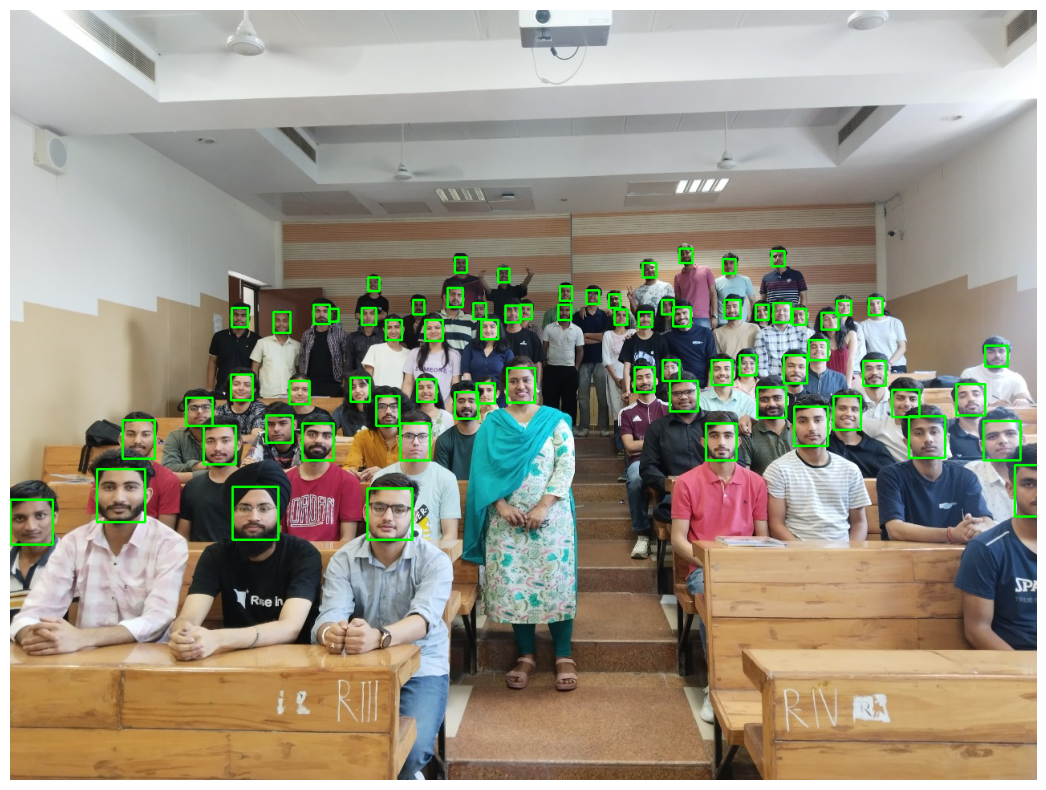

In [4]:
for i, face in enumerate(faces, start=1):
    x1, y1, x2, y2 = face.bbox.astype(int)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)
    
    face_crop = img[y1:y2, x1:x2]
    cv2.imwrite(str(output_dir / f'{i}.jpg'), face_crop)

annotated = rgb_img.copy()
for face in faces:
    x1, y1, x2, y2 = face.bbox.astype(int)
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(16, 10))
plt.imshow(annotated)
plt.axis('off')
plt.show()

## Cosine Similarity (Similarity Matching from embeddings stored in DB)

In [27]:
def cosine_similarity(a, b):
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    if a_norm == 0 or b_norm == 0:
        return 0.0
    return np.dot(a, b) / (a_norm * b_norm)

#### Loading the saved embeddings

In [ ]:
emb = np.load('embeddings.npz')
names = emb['names']
embeddings = emb['embeddings']

In [14]:
names

array(['Saina Saini,23BCS103', 'Saksham Chhabra,23BCS098',
       'Samar Kumar,23BCS099', 'Shagun Rana,23BCS105',
       'Shanpreet Singh,23BCS107', 'Soham Juneja,23BCS110',
       'Sojal,23BEE095', 'Srishti Chamoli,23BCS111', 'Sujal,23BCS113',
       'Tanishk Saini,23BCS114', 'Tanishka Khandelwal,23BCS115',
       'Tanmay Daroch,23BEE108', 'Tanush Dang,23BCS117',
       'Ujjwal Kumar,23BCS131', 'Ujjwal Maheshwari,23BCS118',
       'Yash Sisodia,23BEE117'], dtype='<U28')

In [15]:
embeddings.shape

(16, 512)

#### Matching the current detected faces with the embeddings

In [36]:
present = set()
count = 0
for name, embedding in zip(names, embeddings):     ## For each known embedding, compare with detected face embeddings
    for i, face_embedding in enumerate(face_emb):
        similarity = cosine_similarity(embedding, face_embedding)
        if similarity > 0.5:
            print(f'{name} is present.')
            present.add(name)
            count += 1
print(f'Total present: {len(present)}')

Saina Saini,23BCS103 is present.
Saksham Chhabra,23BCS098 is present.
Samar Kumar,23BCS099 is present.
Shagun Rana,23BCS105 is present.
Shanpreet Singh,23BCS107 is present.
Soham Juneja,23BCS110 is present.
Sojal,23BEE095 is present.
Tanishk Saini,23BCS114 is present.
Tanishka Khandelwal,23BCS115 is present.
Tanush Dang,23BCS117 is present.
Ujjwal Kumar,23BCS131 is present.
Total present: 11
